<a href="https://colab.research.google.com/github/ltd03112007-lab/BTVN/blob/main/2.11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install scikit-fuzzy

In [ ]:
pip install numpy

In [42]:
import skfuzzy as fuzz
import numpy as np
import skfuzzy.control as ctrl
distance= ctrl.Antecedent(np.arange(0,51,1), 'distance')
traffic_condition= ctrl.Antecedent(np.arange(0,101,1),'traffic_condition')
demand= ctrl.Antecedent(np.arange(0,101,1),'demand')
weather_condition= ctrl.Antecedent(np.arange(0,30,1),'weather_condition')
customer_rating= ctrl.Antecedent(np.arange(1,5.1,0.1),'customer_rating')
ride_punctuality= ctrl.Antecedent(np.arange(0,101,1), 'ride_punctuality')
price= ctrl.Consequent(np.arange(0,101,1),'price')
point= ctrl.Consequent(np.arange(0,101,1),'point')


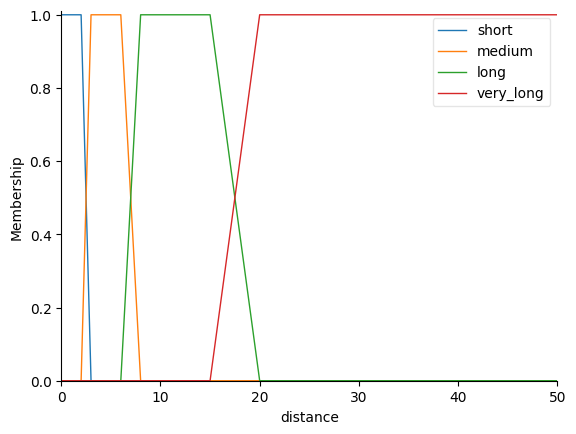

In [43]:
distance ['short']= fuzz.trapmf(distance.universe, [0,0,2,3])
distance['medium']=fuzz.trapmf(distance.universe, [2,3,6,8])
distance['long']=fuzz.trapmf(distance.universe, [6,8,15,20])
distance['very_long']=fuzz.trapmf(distance.universe, [15,20,50,50])
distance.view()

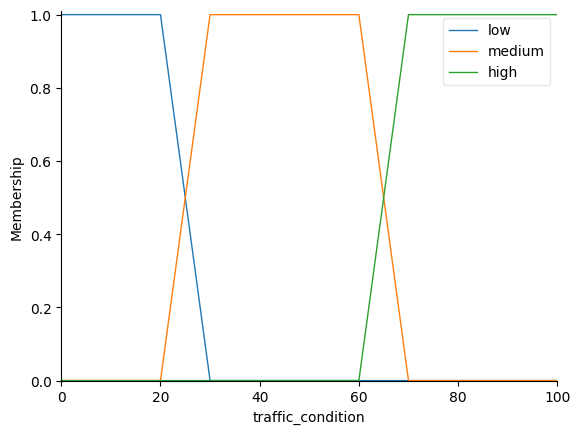

In [44]:
traffic_condition['low']=fuzz.trapmf(traffic_condition.universe, [0,0,20,30])
traffic_condition['medium']=fuzz.trapmf(traffic_condition.universe, [20,30,60,70])
traffic_condition['high']=fuzz.trapmf(traffic_condition.universe, [60,70,100,100])
traffic_condition.view()

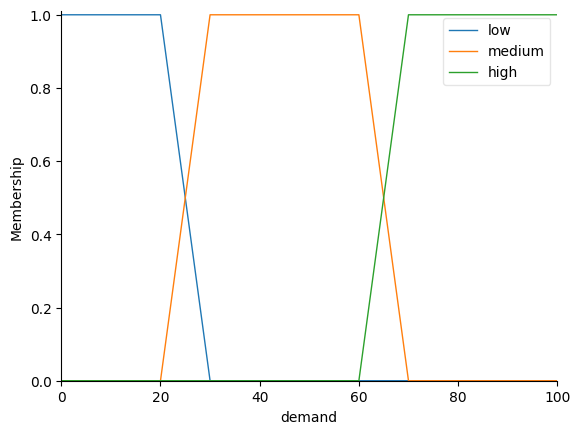

In [46]:
demand['low']=fuzz.trapmf(demand.universe, [0,0,20,30])
demand['medium']=fuzz.trapmf(demand.universe, [20,30,60,70])
demand['high']=fuzz.trapmf(demand.universe, [60,70,100,100])
demand.view()

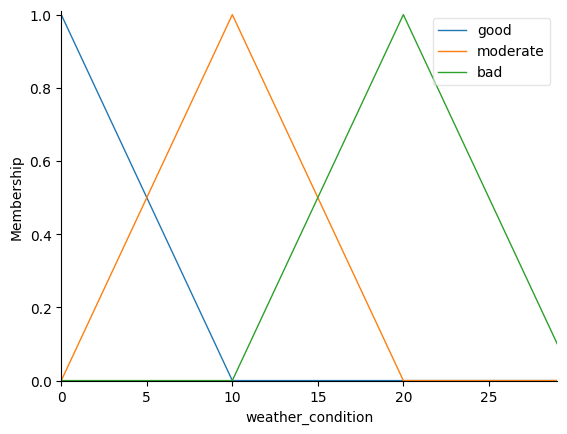

In [47]:
weather_condition['good']=fuzz.trimf(weather_condition.universe, [0,0,10])
weather_condition['moderate']=fuzz.trimf(weather_condition.universe, [0,10,20])
weather_condition['bad']=fuzz.trimf(weather_condition.universe, [10,20,30])
weather_condition.view()

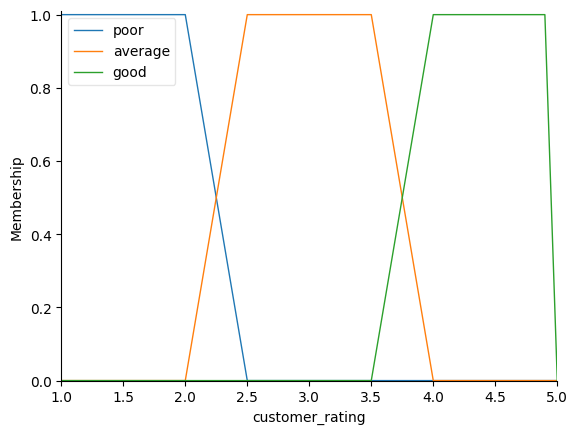

In [48]:
customer_rating['poor']=fuzz.trapmf(customer_rating.universe, [1,1,2,2.5])
customer_rating['average']=fuzz.trapmf(customer_rating.universe, [2,2.5,3.5,4])
customer_rating['good']=fuzz.trapmf(customer_rating.universe, [3.5,4,5,5])
customer_rating.view()

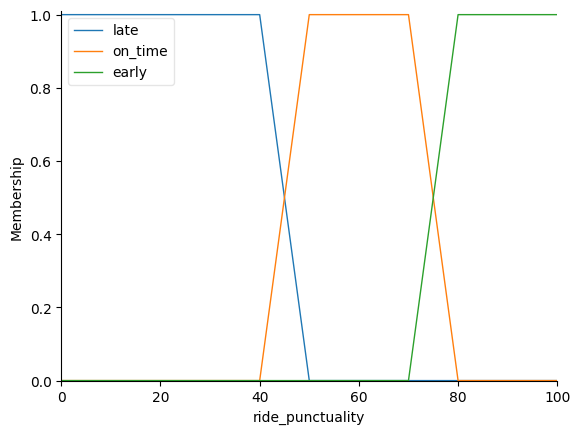

In [49]:
ride_punctuality['late']=fuzz.trapmf(ride_punctuality.universe, [0,0,40,50])
ride_punctuality['on_time']=fuzz.trapmf(ride_punctuality.universe, [40,50,70,80])
ride_punctuality['early']=fuzz.trapmf(ride_punctuality.universe, [70,80,100,100])
ride_punctuality.view()

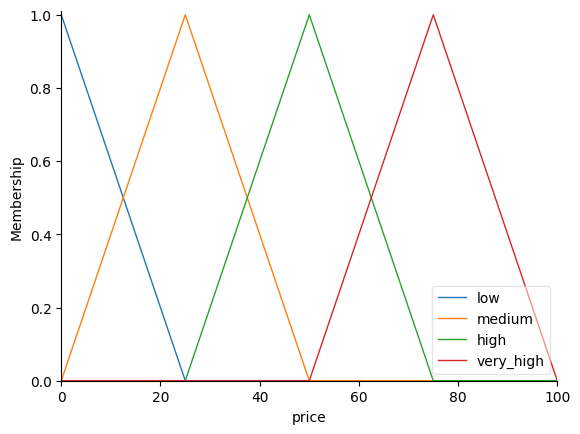

In [50]:
price['low']=fuzz.trimf(price.universe, [0,0,25])
price['medium']=fuzz.trimf(price.universe, [0,25,50])
price['high']=fuzz.trimf(price.universe, [25,50,75])
price['very_high']=fuzz.trimf(price.universe, [50,75,100])
price.view()

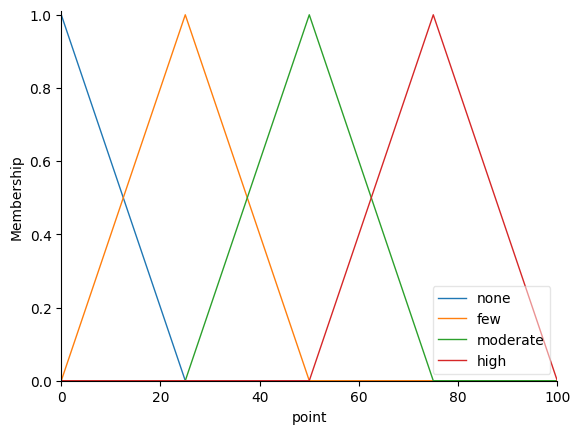

In [51]:
point['none']=fuzz.trimf(point.universe, [0,0,25])
point['few']=fuzz.trimf(point.universe, [0,25,50])
point['moderate']=fuzz.trimf(point.universe, [25,50,75])
point['high']=fuzz.trimf(point.universe, [50,75,100])
point.view()

In [52]:
rule1=ctrl.Rule(distance['short']&traffic_condition['low']&demand['low'], price['low'])
rule2=ctrl.Rule(distance['short']&traffic_condition['medium']&demand['high'], price['medium'])
rule3=ctrl.Rule(distance['medium']&traffic_condition['high']&demand['high'], price['high'])
rule4=ctrl.Rule(distance['long']&traffic_condition['medium']&weather_condition['good'], price['medium'])
rule5=ctrl.Rule(distance['long']&traffic_condition['high']&weather_condition['bad'], price['very_high'])
rule6=ctrl.Rule(distance['very_long']&traffic_condition['high']&demand['high'], price['very_high'])
rule7=ctrl.Rule(distance['medium']&traffic_condition['low']&demand['low'], price['medium'])
rule8=ctrl.Rule(distance['short']&traffic_condition['high']&weather_condition['bad'], price['high'])
rule9=ctrl.Rule(distance['very_long']&weather_condition['bad'], price['very_high'])
rule10=ctrl.Rule(distance['medium']&traffic_condition['medium']&weather_condition['moderate'], price['medium'])
rule11=ctrl.Rule(customer_rating['good']&ride_punctuality['early'], point['high'])
rule12=ctrl.Rule(customer_rating['average']&ride_punctuality['on_time'], point['moderate'])
rule13=ctrl.Rule(customer_rating['poor']&ride_punctuality['late'], point['none'])
rule14=ctrl.Rule(distance['medium']&traffic_condition['medium']&customer_rating['good'], point['moderate'])
rule15=ctrl.Rule(distance['long']&traffic_condition['high']&ride_punctuality['on_time'], point['high'])
rule16=ctrl.Rule(customer_rating['poor']&ride_punctuality['late'], point['none'])
rule17=ctrl.Rule(distance['very_long']&customer_rating['good']&weather_condition['bad'], point['few'])
rule18=ctrl.Rule(distance['short']&customer_rating['average']&ride_punctuality['on_time'], point['few'])
rule19=ctrl.Rule(distance['long']&traffic_condition['high']&ride_punctuality['late'], point['few'])
rule20=ctrl.Rule(distance['medium']&customer_rating['good']&weather_condition['moderate'], point['moderate'])

số tiền của chuyến đi là: 25.0
điểm thưởng cho khách hàng là: 50.0


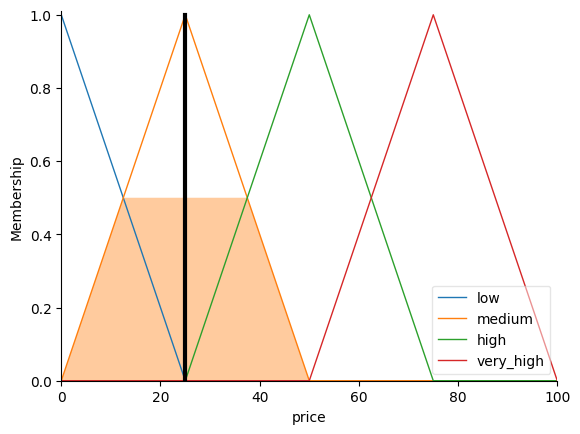

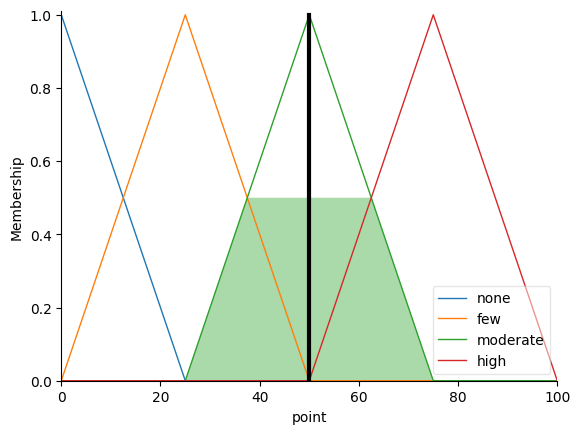

In [53]:
control_system=ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8,rule9,rule10,rule11,rule12,rule13,rule14,rule15,rule16,rule17,rule18,rule19,rule20])
ride_system=ctrl.ControlSystemSimulation(control_system)
ride_system.input['distance']=7
ride_system.input['traffic_condition']=60
ride_system.input['demand']=50
ride_system.input['weather_condition']=5
ride_system.input['customer_rating']=4.8
ride_system.input['ride_punctuality']=70
ride_system.compute()
print('số tiền của chuyến đi là:',ride_system.output['price'])
print('điểm thưởng cho khách hàng là:',ride_system.output['point'])
price.view(sim=ride_system)
point.view(sim=ride_system)